In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

import xgboost as xgb

np.random.seed(0)
tf.random.set_seed(0)

# Data Intake

In [ ]:
# read in data
seoul_bikes = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

# rename columns
seoul_bikes = seoul_bikes.rename(
    columns={
        'Date': 'date',
        'Rented Bike Count': 'rented_bike_count',
        'Hour': 'hour',
        'Temperature(°C)': 'temperature',
        'Humidity(%)': 'humidity',
        'Wind speed (m/s)': 'wind_speed',
        'Visibility (10m)': 'visibility',
        'Dew point temperature(°C)': 'dew_point_temp',
        'Solar Radiation (MJ/m2)': 'solar_radiation',
        'Rainfall(mm)': 'rainfall',
        'Snowfall (cm)': 'snowfall',
        'Seasons': 'seasons',
        'Holiday': 'holiday',
        'Functioning Day': 'functioning_day'
    })

# print shape and head
print(seoul_bikes.shape)
seoul_bikes.head()

#functioning day - categorical
#holiday - categorical
#seasons - categorical
#snowfall
#rainfall
#solar radiation
#dew point temperature
#visibility
#wind speed
#humidity
#temperature
#hour
#date

#Y = Rented Bike Count

(8760, 14)


,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


# Cleaning

In [11]:
# filter out non-functioning hours
print('Number of non-functioning hours:',
      len(seoul_bikes[seoul_bikes['functioning_day'] == 'No']))

seoul_bikes = seoul_bikes[seoul_bikes['functioning_day'] == 'Yes']

print('Remaining rows: ',
      len(seoul_bikes))

Number of non-functioning hours: 0
Remaining rows:  8465


In [12]:
# add datetime column for time series sorting
seoul_bikes["datetime"] = pd.to_datetime(seoul_bikes["date"], dayfirst=True) + pd.to_timedelta(seoul_bikes["hour"], unit="h")
seoul_bikes = seoul_bikes.sort_values("datetime").reset_index(drop=True)

seoul_bikes.head(25)

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,datetime,doy
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00,335
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00,335
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00,335
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00,335
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00,335
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 05:00:00,335
6,2017-12-01,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 06:00:00,335
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 07:00:00,335
8,2017-12-01,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 08:00:00,335
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 09:00:00,335


In [13]:
# convert date to datetime
print(seoul_bikes['date'].dtype)
seoul_bikes['date'] = pd.to_datetime(seoul_bikes['date'], format='%d/%m/%Y')
print(seoul_bikes['date'].dtype)

# create date to day of year
seoul_bikes['doy'] = seoul_bikes['date'].dt.dayofyear
print(np.sort(seoul_bikes['doy'].unique()))
print(len(seoul_bikes['doy'].unique()))

#Dates that are not being tracked
all_dates = pd.date_range(
    start=seoul_bikes['date'].min(),
    end=seoul_bikes['date'].max()
)
missing_dates = all_dates.difference(seoul_bikes['date'])
print(f'\nThere are {missing_dates} missing dates')
print("Here are the missing dates:", len(missing_dates))


datetime64[ns]
datetime64[ns]
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146
 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164
 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
 237 238 239 240 241 

In [16]:
seoul_bikes = seoul_bikes.sort_values("datetime").reset_index(drop=True)
seoul_bikes.head(25)

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,datetime,doy
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00,335
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00,335
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00,335
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00,335
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00,335
5,2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 05:00:00,335
6,2017-12-01,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 06:00:00,335
7,2017-12-01,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 07:00:00,335
8,2017-12-01,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 08:00:00,335
9,2017-12-01,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 09:00:00,335


In [15]:
# check for missing values
#seoul_bikes.isnull().sum()
seoul_bikes.isna().sum()

date                 0
rented_bike_count    0
hour                 0
temperature          0
humidity             0
wind_speed           0
visibility           0
dew_point_temp       0
solar_radiation      0
rainfall             0
snowfall             0
seasons              0
holiday              0
functioning_day      0
datetime             0
doy                  0
dtype: int64

In [30]:
# create lag features
seoul_bikes["lag1"] = seoul_bikes["rented_bike_count"].shift(1)
seoul_bikes["lag24"] = seoul_bikes["rented_bike_count"].shift(24)
seoul_bikes["rolling3"] = (seoul_bikes["rented_bike_count"].shift(1).rolling(3).mean())

seoul_bikes = seoul_bikes.dropna().reset_index(drop=True)

seoul_bikes.head(2)

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,datetime,doy,lag1,lag24,rolling3
0,2017-12-06,145,0,-2.8,77,0.0,331,-6.2,0.0,0.1,0.1,Winter,No Holiday,Yes,2017-12-06 00:00:00,340,244.0,216.0,350.666667
1,2017-12-06,144,1,-3.0,79,0.0,293,-6.1,0.0,0.0,0.3,Winter,No Holiday,Yes,2017-12-06 01:00:00,340,145.0,198.0,260.666667


In [31]:
# normalize values

# identify numeric and non-numeric columns
num_cols = ['rented_bike_count','hour','temperature','humidity','wind_speed',
            'visibility','dew_point_temp','solar_radiation','rainfall',
            'snowfall','doy']

# exclude functioning day from non-numeric columns b/c we've filtered it to one value
non_num_cols = ['date','seasons','holiday']

# normalize numeric values
# note: scaling for EDA purposes only, will fit scaler only on training data in modeling portion
scaler = MinMaxScaler()
normalized = scaler.fit_transform(seoul_bikes[num_cols])
norm_bikes = pd.DataFrame(normalized, columns=num_cols)

# add non-numeric columns into new dataframe
for col in non_num_cols:
    norm_bikes[col] = seoul_bikes[col]

# Visualizations

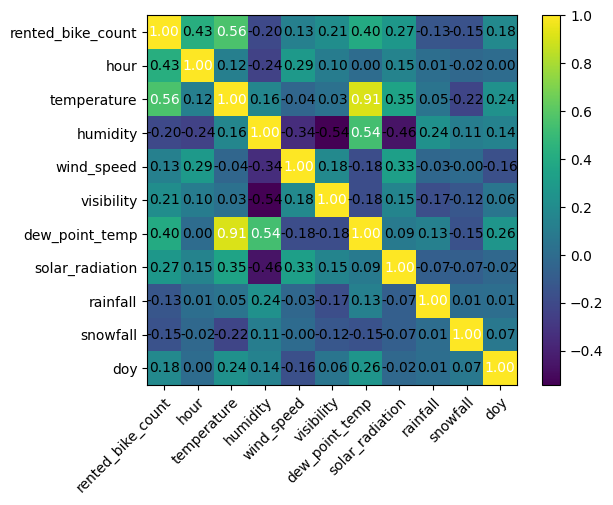

In [32]:
# numeric variable correlations
correlations = norm_bikes[num_cols].corr()

# create heatmap of correlations
hm = heatmap(
    correlations.values,
    row_names=correlations.index,
    column_names=correlations.columns
)
plt.show()


#### Correlation Interpretation:

Rented bike demand shows moderate linear correlations with several variables: temperature (0.56), hour of day (0.43), and dew point temperature (0.40).

Temperature and dew point temperature are highly correlated (0.91), indicating strong multicollinearity so we can remove one of these variables. Since dew point has a correlation of 0.4, we decided to remove this and keep the temperature variable. The only weak correlations seen are rainfall and snowfall with bike demand, and day of year with bike demand(0.17).

In [33]:
# remove irrelevant columns
norm_bikes = norm_bikes[[
    'rented_bike_count',
    'hour',
    'temperature',
    'humidity',
    'wind_speed',
    'visibility',
    'rainfall',
    'snowfall',
    'doy',
    'holiday',
    'seasons']
    ]

# print final shape
print(norm_bikes.shape)

(8345, 11)


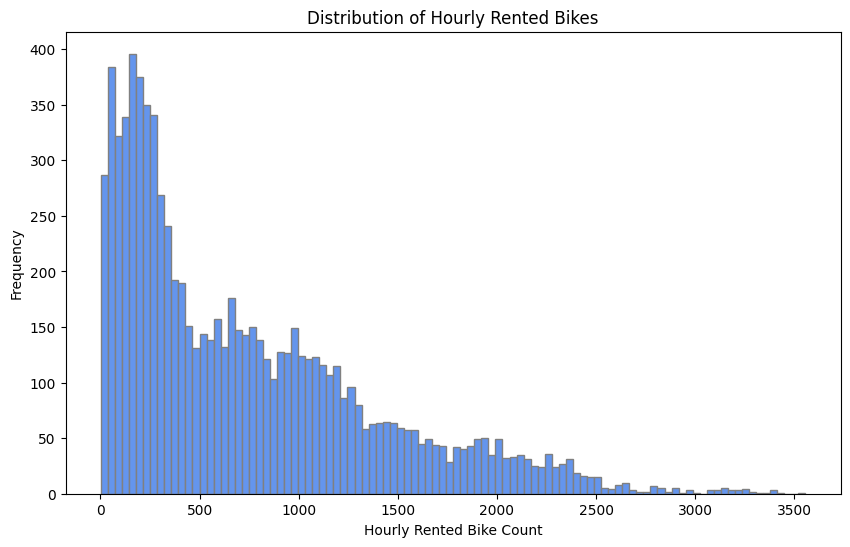

In [34]:
# histogram
plt.figure(figsize=(10,6))
plt.hist(seoul_bikes['rented_bike_count'], bins=100, color='cornflowerblue', edgecolor='grey')
plt.title('Distribution of Hourly Rented Bikes')
plt.xlabel('Hourly Rented Bike Count')
plt.ylabel('Frequency')
plt.show()

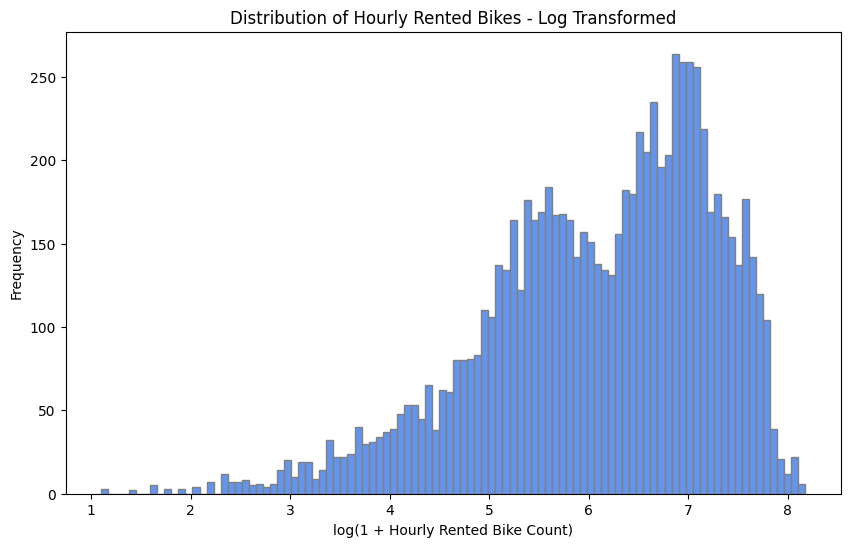

In [35]:
# histogram: log transformed
# We notice the right skew with a long tail in the previous plot and can cause issues for linear regression. To subsidize this error we introduce a log transform.
plt.figure(figsize=(10,6))
plt.hist(np.log1p(seoul_bikes['rented_bike_count']), bins=100, color='cornflowerblue', edgecolor='grey')
plt.title('Distribution of Hourly Rented Bikes - Log Transformed')
plt.xlabel('log(1 + Hourly Rented Bike Count)')
plt.ylabel('Frequency')
plt.show()

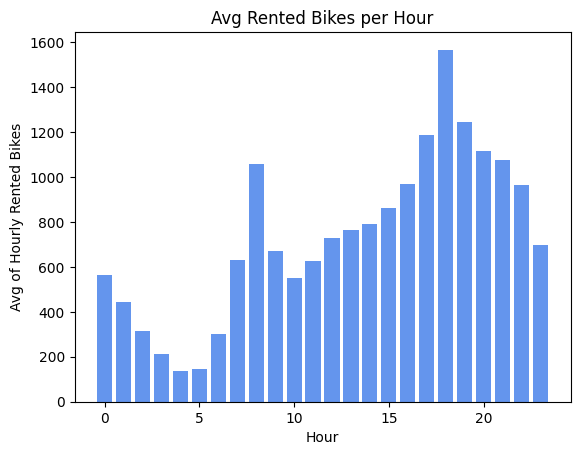

In [36]:
# other visualizations (non-normalized data for interpretability)

# avg rented bikes by hour
hourly_avg = seoul_bikes[['hour','rented_bike_count']].groupby('hour').mean().reset_index()

plt.bar(
    hourly_avg['hour'],
    hourly_avg['rented_bike_count'],
    color='cornflowerblue'
)
plt.title('Avg Rented Bikes per Hour')
plt.xlabel('Hour')
plt.ylabel('Avg of Hourly Rented Bikes')
plt.show()

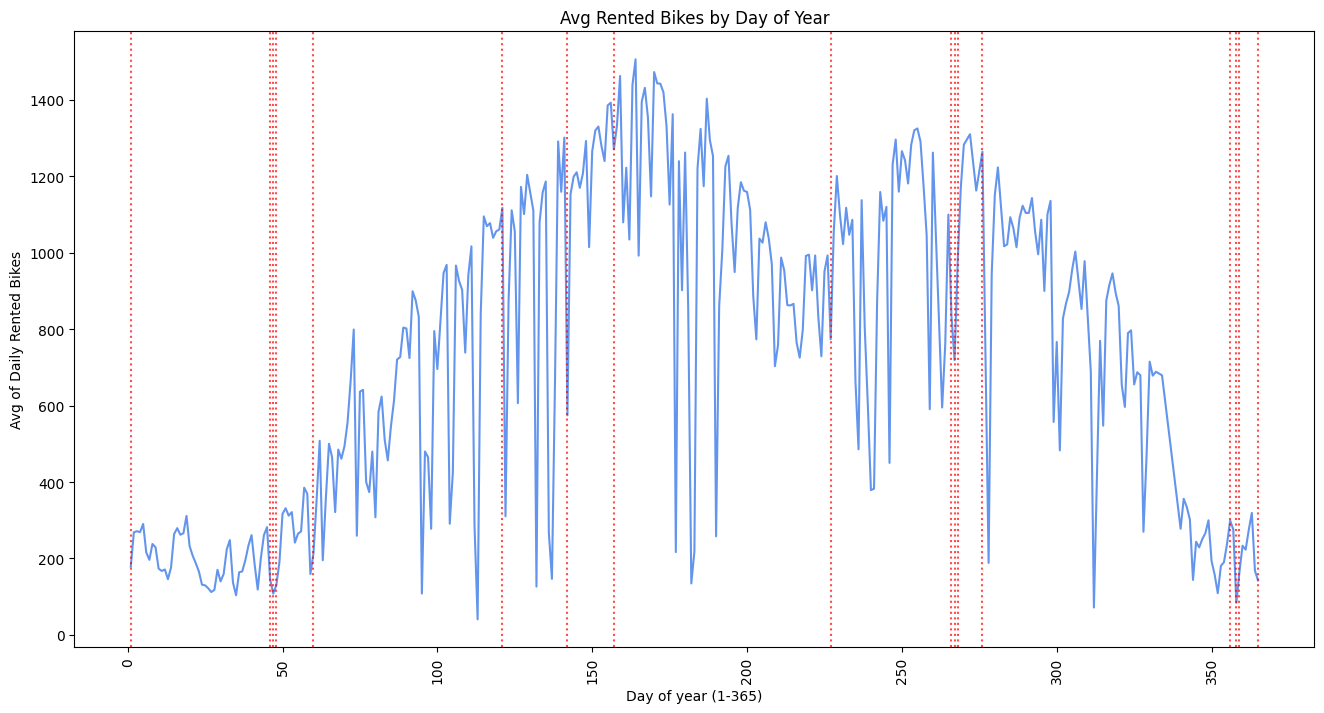

In [37]:
# avg rented bikes by day
print('\n')
daily_avg = seoul_bikes[['doy', 'rented_bike_count']].groupby('doy').mean().reset_index().sort_values(by='doy')
plt.figure(figsize=(16,8))
plt.plot(
    daily_avg['doy'],
    daily_avg['rented_bike_count'],
    color='cornflowerblue'
)
plt.title('Avg Rented Bikes by Day of Year')
plt.xticks(rotation=90)
plt.xlabel('Day of year (1-365)')
plt.ylabel('Avg of Daily Rented Bikes')

# add vertical red dotted lines on holidays
holiday_doy = seoul_bikes[seoul_bikes['holiday'] == 'Holiday']['doy'].unique()
for h in holiday_doy:
    plt.axvline(x=h, color='red', linestyle='dotted', alpha=0.7)

plt.show()

In [38]:
# compare holiday vs non holiday avg bike rentals
seoul_bikes.groupby('holiday')['rented_bike_count'].mean()

holiday
Holiday       529.154412
No Holiday    745.130276
Name: rented_bike_count, dtype: float64

# Modeling

#### Data Preprocessing

In [40]:
# create X and y datasets
features = [
    'hour',
    'temperature',
    'humidity',
    'wind_speed',
    'visibility',
    'rainfall',
    'snowfall',
    'doy',
    'holiday',
    'seasons',
    'lag1',
    'lag24',
    'rolling3'
]

X = seoul_bikes[features]
y = seoul_bikes['rented_bike_count']

In [41]:
# encode categorical variable (holiday)
X = pd.get_dummies(X, columns=['holiday', 'seasons'], drop_first=True)

In [ ]:
# cyclic encoding for hour and day of year
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

X["doy_sin"] = np.sin(2 * np.pi * X["doy"] / 365)
X["doy_cos"] = np.cos(2 * np.pi * X["doy"] / 365)

X = X.drop(columns=["hour", "doy"])

KeyError: 'hour'

In [43]:
# time based data split into train/val/test: 60/20/20
train_end = int(len(X) * 0.6)
val_end = int(len(X) * 0.8)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]


# previous random split (not time based), ignore
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1234)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = .5, random_state=1234)

# print(len(X_train), len(X_val), len(X_test))
# print(len(y_train), len(y_val), len(y_test))

In [44]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and print regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2:   {r2:.4f}")

    return {'mae': mae, 'rmse': rmse, 'r2': r2}

#### Baseline Model

In [22]:
# baseline model: predicts the training set mean bike rental count
baseline = y_train.mean()
print('Mean bike rental: ', baseline)

# evaluate baseline on validation data
y_val_baseline = [baseline] * len(y_val)
print('Y val prediction length: ', len(y_val_baseline))

evaluate_model(y_val, y_val_baseline, "Baseline (Mean)")

Mean bike rental:  728.4569797204174
Y val prediction length:  1693

Baseline (Mean) Performance:
MAE:  524.89
RMSE: 644.87
R^2:   -0.0000


{'mae': 524.8865106741715,
 'rmse': 644.8681581981735,
 'r2': -2.718545906654768e-05}

##### Baseline model evaluation:

Predicts the mean value of bike rental count in the training dataset: 728.

MAE: on average, the model is off by ~535 bikes per hour. RMSE: ~645 (large errors are punished more).

R squared is slightly negative at -2.7e-05: baseline model explains essentially no variance in bike demand.

#### Linear Regression

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#X_test_scaled[:3]

In [46]:
# linear regression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

# validation data predictions
y_val_linreg = linreg.predict(X_val_scaled)

# evaluate linear regression model on validation data
evaluate_model(y_val, y_val_linreg, "Linear Regression")


Linear Regression Performance:
MAE:  216.24
RMSE: 287.25
R^2:   0.7939


{'mae': 216.23771191428352,
 'rmse': 287.25448043569486,
 'r2': 0.7939157696492681}

##### Linear regression model evaluation:

Linear regression model predicts bike rental count using temporal and environmental features.

MAE: on average, the model is off by ~216 bikes per hour, which is an improvement over the baseline. RMSE is ~287, indicating that large errors have been reduced compared to the baseline model.

R squared is 0.79, so this model explains approximately 79% of the variance in bike demand, a large improvement relative to the baseline.

#### FFNN

In [48]:
def build_compile_ffnn(hp):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)
    num_features = X_train_scaled.shape[1]
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(num_features,), name='Input'))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(tf.keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        if hp.Boolean(f'dropout_{i}'):
            model.add(tf.keras.layers.Dropout(0.2))

    model.add(tf.keras.layers.Dense(units=1))

    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

In [49]:
tuner = kt.RandomSearch(
    hypermodel=build_compile_ffnn,
    objective='val_mae',
    max_trials=10,
    executions_per_trial=1,
    directory='search_results',
    project_name='seoul_bike_random'
)

2026-04-13 20:03:34.963989: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-13 20:03:34.967464: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-13 20:03:34.968633: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-13 20:03:34.968820: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-13 20:03:34.969395: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Reloading Tuner from search_results/seoul_bike_random/tuner0.json


In [50]:
# early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Start the search
tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=False
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)
tuner.results_summary()

Results summary
Results in search_results/seoul_bike_random
Showing 10 best trials
Objective(name="val_mae", direction="min")

Trial 04 summary
Hyperparameters:
num_layers: 2
units_0: 96
dropout_0: False
learning_rate: 0.0005
units_1: 128
dropout_1: False
units_2: 192
dropout_2: True
Score: 320.9404296875

Trial 03 summary
Hyperparameters:
num_layers: 2
units_0: 192
dropout_0: True
learning_rate: 0.0005
units_1: 192
dropout_1: False
units_2: 192
dropout_2: False
Score: 321.3248596191406

Trial 09 summary
Hyperparameters:
num_layers: 1
units_0: 160
dropout_0: False
learning_rate: 0.0005
units_1: 256
dropout_1: True
units_2: 192
dropout_2: False
Score: 540.9051513671875

Trial 02 summary
Hyperparameters:
num_layers: 1
units_0: 96
dropout_0: False
learning_rate: 0.0005
units_1: 64
dropout_1: True
units_2: 192
dropout_2: False
Score: 573.9552612304688

Trial 07 summary
Hyperparameters:
num_layers: 1
units_0: 96
dropout_0: True
learning_rate: 0.0005
units_1: 64
dropout_1: False
units_2: 160

In [51]:
print("The best hyperparameters are:")
for param, value in best_hps.values.items():
    print(f"- {param}: {value}")

The best hyperparameters are:
- num_layers: 2
- units_0: 96
- dropout_0: False
- learning_rate: 0.0005
- units_1: 128
- dropout_1: False
- units_2: 192
- dropout_2: True


In [52]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,273 (55.75 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ffnn predictions
y_val_ffnn = best_model.predict(X_val_scaled).flatten()

# validation metrics
metrics_ffnn = evaluate_model(y_val, y_val_ffnn, "Tuned FFNN")

Epoch 1/50


2026-04-13 20:05:42.130628: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 729436.3125 - mae: 596.7784 - rmse: 854.0704 - val_loss: 1170408.1250 - val_mae: 901.5878 - val_rmse: 1081.8540
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 526150.0625 - mae: 561.4127 - rmse: 725.3620 - val_loss: 483448.7500 - val_mae: 534.1278 - val_rmse: 695.3048
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 402764.6562 - mae: 512.3756 - rmse: 634.6375 - val_loss: 272292.2500 - val_mae: 373.6306 - val_rmse: 521.8163
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 410063.6875 - mae: 504.2564 - rmse: 640.3622 - val_loss: 288805.3125 - val_mae: 386.0945 - val_rmse: 537.4061
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 397046.7812 - mae: 503.7895 - rmse: 630.1165 - val_loss: 324807.9688 - val_mae: 414.4345 - val_rmse: 569.9193
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 387999.2812 - mae: 504.9883 - rmse: 622.8959 - val_loss: 350329.6875 - val_mae: 434.5753 - va

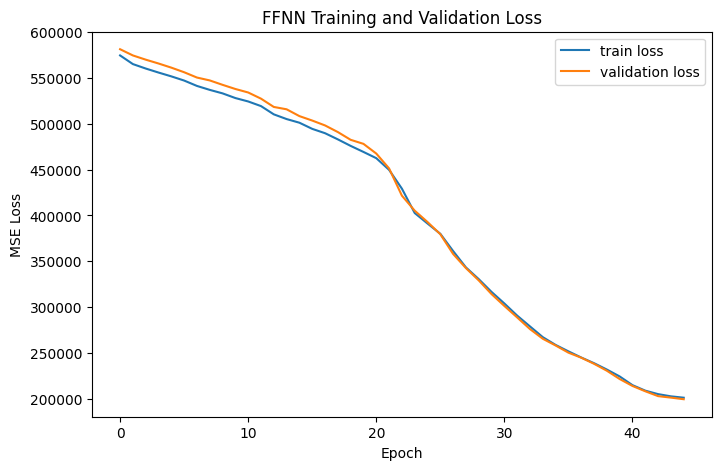

In [39]:
# plot training and validation MSE loss by epoch
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'][5:], label='train loss')
plt.plot(history.history['val_loss'][5:], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('FFNN Training and Validation Loss')
plt.legend()
plt.show()

##### FFNN evaluation:

The keras tuned feedforward neural network achieved a validation MAE of 374, RMSE of 522 and R squared of 0.32, so the simpler linear regression outperformed this more complex model. This could be explained as the data is relatively structured time series data with linear patterns.

#### Gradient Boosted Trees / XGBoost

In [54]:
# tested log transforming y variables and then untransforming to read results
# this did not improve performance or overfitting
#y_train_log = np.log1p(y_train)
#y_val_log = np.log1p(y_val)

# convert arrays to dmatrices (xgboost function needs data in dmatrix format)
xgb_train = xgb.DMatrix(X_train_scaled, label=y_train)
xgb_val = xgb.DMatrix(X_val_scaled, label=y_val)

# train model
xgb_model = xgb.train(
    dtrain=xgb_train,
    params={  # define hyperparameterse
      'seed':0,  # set seed
      'objective':'reg:squarederror',  # squared error regression
      'learning_rate':0.01,
      'max_depth':6,  # max depth of trees
      'subsample':0.9,  # what proportion of data is used in each tree
      'colsample_bytree':0.9,  # what proportion of features used in each tree
      'eval_metric':'rmse' # evaluate on root mean squared error

      # gamma, alpha, lambda, and min_child_weight added to try to improve overfitting
      # they improved overfitting, but reduced model performance
      #'gamma':10,
      #'min_child_weight':5
      #'lambda':50,
      #'alpha':0.5
      #'max_bin':100
    },
    num_boost_round=50000,  # max number of trees to build (n_estimators)
    evals=[(xgb_train, 'train'), (xgb_val, 'val')],  # define train/val sets
    early_stopping_rounds=250,  # stop if rmse doesnt improve after 50 trees
    verbose_eval=50
)

# make predictions and store for evaluation
xgb_pred = xgb_model.predict(xgb_val)

# evaluate model performance
xgb_perf = evaluate_model(y_val, xgb_pred, 'XGBoost')


[0]	train-rmse:622.87012	val-rmse:732.75871
[50]	train-rmse:397.87612	val-rmse:468.72080
[100]	train-rmse:262.47248	val-rmse:314.76836
[150]	train-rmse:182.51595	val-rmse:233.87538
[200]	train-rmse:136.11298	val-rmse:195.32635
[250]	train-rmse:110.35430	val-rmse:179.58644
[300]	train-rmse:95.41155	val-rmse:173.67471
[350]	train-rmse:86.23092	val-rmse:171.68401
[400]	train-rmse:80.25067	val-rmse:171.81804
[450]	train-rmse:75.82198	val-rmse:172.58798
[500]	train-rmse:72.57967	val-rmse:173.59384
[550]	train-rmse:69.59409	val-rmse:174.13569
[600]	train-rmse:67.10377	val-rmse:174.54506
[620]	train-rmse:66.13070	val-rmse:174.59581

XGBoost Performance:
MAE:  115.58
RMSE: 174.60
R^2:   0.9239


Overfitting:

XGBoost is overfitting. The final training RMSE shows a value of 10.45 and the final validation RMSE shows 197.94. Attempted to reduce overfitting by converting hour and day of year (doy) variables into a cyclical format, as hour 0 and hour 23  are only 1 hour apart not 23 hours apart. Created two new variables, a sine and cosine calculation on the hour variable. Dropped the hour variable and repeated the process with some improvements in model performance and less overfitting.

In [55]:
# convert test data to DMatrix
xgb_test = xgb.DMatrix(X_test_scaled, label=y_test)

# make predictions on test set
xgb_test_pred = xgb_model.predict(xgb_test)

# evaluate test performance
xgb_test_perf = evaluate_model(y_test, xgb_test_pred, 'XGBoost (Test)')


XGBoost (Test) Performance:
MAE:  96.15
RMSE: 145.04
R^2:   0.9405
